# Advanced Retail Analytics: Customer Segmentation & Retention

**Objective:** To perform a comprehensive analysis on 540,000+ historical retail transactions to identify high-value customer groups and analyze their purchasing lifecycle. 
**Business Impact:** This project delivers two core strategic frameworks:
1.  **RFM Segmentation:** Identifying high-value "Champions" vs. "At-Risk" customers to optimize marketing spend.
2.  **Cohort Analysis:** Tracking monthly retention rates to identify exact points of customer churn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# 2. Clean the Data
df.dropna(subset=['CustomerID'], inplace=True)
df = df[df['Quantity'] > 0]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Data cleaned. Total valid transactions ready for analysis: {df.shape[0]}")

Data cleaned. Total valid transactions ready for analysis: 397924


---
## Phase 1: RFM Customer Segmentation
We will score customers from 1-4 based on their Recency (last purchase), Frequency (total orders), and Monetary Value (total spend) to group them into actionable business tiers.

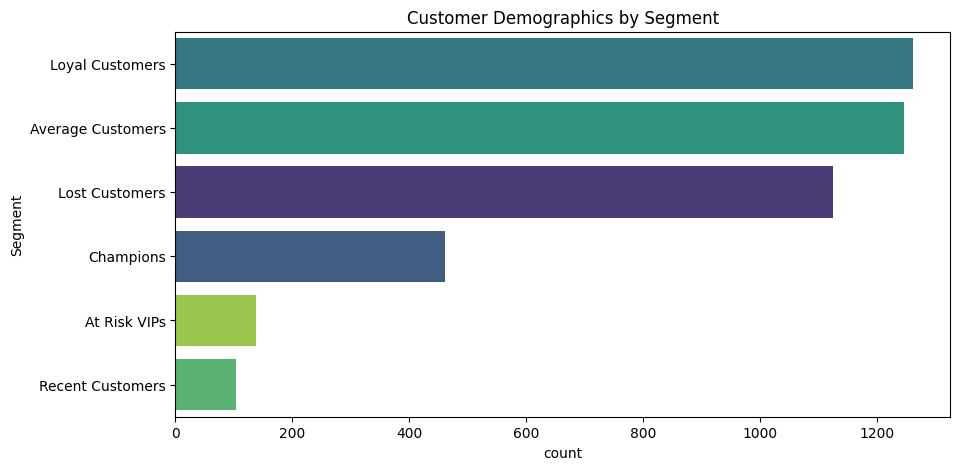

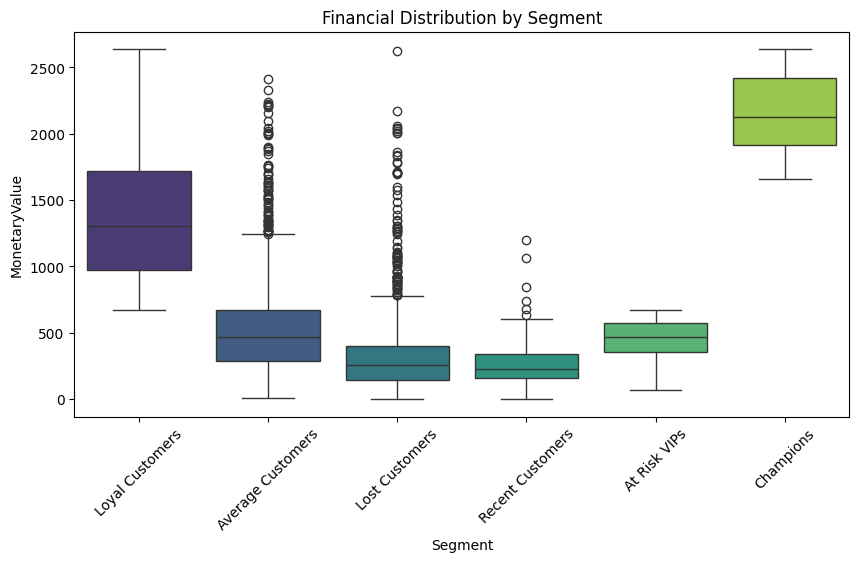

In [2]:
# Create snapshot date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Calculate RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'MonetaryValue'})

# Calculate Quartiles
quantiles = rfm.quantile(q=[0.25, 0.5, 0.75], numeric_only=True).to_dict()

def RScore(x, p, d):
    if x <= d[p][0.25]: return 4
    elif x <= d[p][0.50]: return 3
    elif x <= d[p][0.75]: return 2
    else: return 1

def FMScore(x, p, d):
    if x <= d[p][0.25]: return 1
    elif x <= d[p][0.50]: return 2
    elif x <= d[p][0.75]: return 3
    else: return 4

rfm['R_Quartile'] = rfm['Recency'].apply(RScore, args=('Recency', quantiles,))
rfm['F_Quartile'] = rfm['Frequency'].apply(FMScore, args=('Frequency', quantiles,))
rfm['M_Quartile'] = rfm['MonetaryValue'].apply(FMScore, args=('MonetaryValue', quantiles,))
rfm['RFM_Score'] = rfm.R_Quartile.map(str) + rfm.F_Quartile.map(str) + rfm.M_Quartile.map(str)

# Segment Customers
def segment_customer(df):
    if df['RFM_Score'] == '444': return 'Champions'
    elif df['F_Quartile'] >= 3 and df['M_Quartile'] >= 3: return 'Loyal Customers'
    elif df['R_Quartile'] == 4 and df['F_Quartile'] == 1: return 'Recent Customers'
    elif df['R_Quartile'] <= 2 and df['F_Quartile'] >= 3: return 'At Risk VIPs'
    elif df['R_Quartile'] <= 2 and df['F_Quartile'] == 1: return 'Lost Customers'
    else: return 'Average Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Visualization 1: Segment Demographics
plt.figure(figsize=(10, 5))
sns.countplot(y='Segment', hue='Segment', data=rfm, order=rfm['Segment'].value_counts().index, palette='viridis', legend=False)
plt.title('Customer Demographics by Segment')
plt.show()

# Visualization 2: Financial Impact (Filtered for outliers)
q3 = rfm['MonetaryValue'].quantile(0.85)
filtered_rfm = rfm[rfm['MonetaryValue'] <= q3]

plt.figure(figsize=(10, 5))
sns.boxplot(x='Segment', y='MonetaryValue', data=filtered_rfm, palette='viridis', hue='Segment', legend=False)
plt.title('Financial Distribution by Segment')
plt.xticks(rotation=45)
plt.show()

---
## Phase 2: Cohort Analysis (Customer Retention)
*Business Question: Are we keeping the customers we acquire?*
By grouping customers by the month of their first purchase, we can track exactly when they stop buying from us, allowing us to deploy targeted email campaigns before they churn.

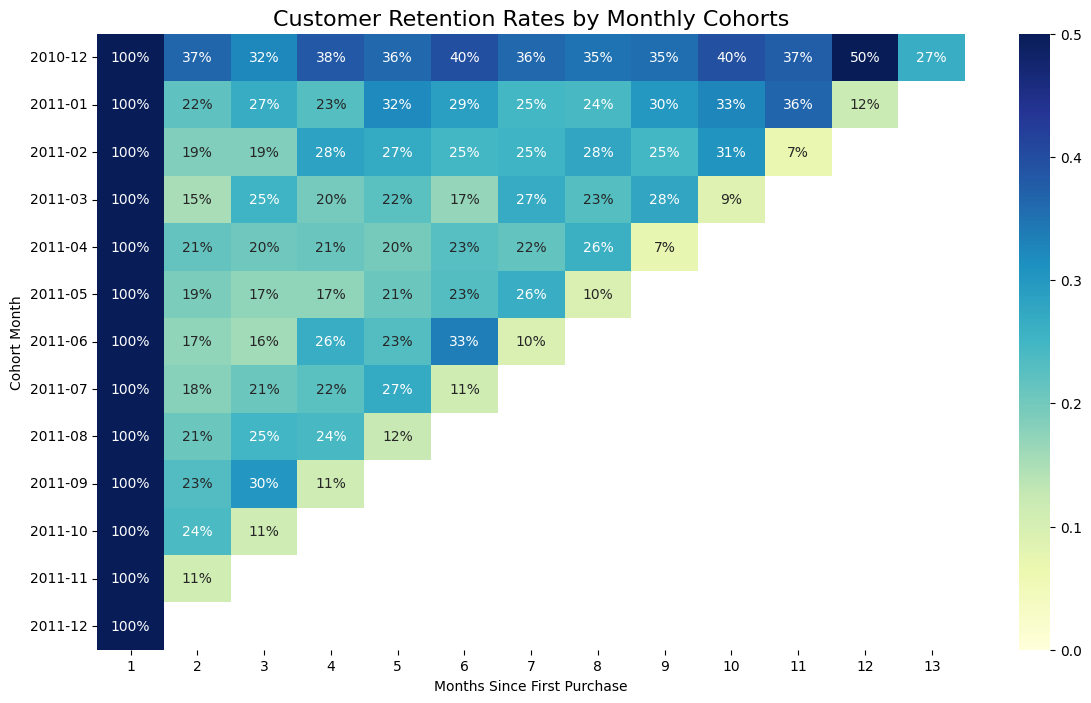

In [3]:
# Create InvoiceMonth and CohortMonth
def get_month(x): return dt.datetime(x.year, x.month, 1)
df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

# Calculate time offset (Cohort Index)
invoice_year = df['InvoiceMonth'].dt.year
invoice_month = df['InvoiceMonth'].dt.month
cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month
df['CohortIndex'] = years_diff * 12 + months_diff + 1

# Pivot Data for Retention
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].apply(pd.Series.nunique).reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Convert to Percentages
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.strftime('%Y-%m')

# Plot the Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=0.5)
plt.title('Customer Retention Rates by Monthly Cohorts', fontsize=16)
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

---
## Strategic Recommendations
1. **Retention Crisis:** The Cohort Analysis shows a massive drop-off (averaging an 80% loss) after month 1. An automated "Welcome Back" discount must be triggered 14 days after a first purchase.
2. **Protect the Champions:** The boxplot proves that a tiny fraction of customers drives the vast majority of revenue. Establish a VIP phone line and early-access catalogs for this segment immediately.